<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/classifier_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data Analytics and Text Mining (6 CFU)

- Project Title: Predicting Online News Popularity
- Professor: Prof. Stefano Lodi
- Author: Safoura Banihashemi
- Academic Year: 2024–2025

## Project Overview

This project focuses on predicting the Online News Popularity through three binary-classification methods using the PySpark library.

1. Logistic Regression
2. Random Forest
3. Gradient Boosted tree

## Dataset Description

The dataset consists of 39,644 articles published by Mashable over a period of two years. It includes a rich set of 61 features extracted from the articles, which can be grouped into:

- Text Features: Word counts, title/content length, and the rate of unique or non-stop words.

- Sentiment & Tonality: Polarity scores, subjectivity scores, and rates of positive vs. negative words (utilizing text mining metrics).

- Metadata & Context: Channel type (Lifestyle, Entertainment, Business, Social Media, Tech, World), publication day of the week, and the popularity of referenced keywords.

- Target Variable: The original dataset contains a continuous count of shares. For this project, this variable is engineered into two distinct classes to frame the task as a binary classification problem.

## Requirements

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "20")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark Version: {spark.version}")

Spark Version: 4.0.2


In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("programmerrdai/online-news-popularity")
print(path)

100%|██████████| 7.33M/7.33M [00:00<00:00, 66.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/programmerrdai/online-news-popularity/versions/1


In [4]:
# Point PySpark to the CSV file inside the downloaded Kaggle directory
csv_path = os.path.join(path, "*.csv")

# Load the dataset directly into a PySpark DataFrame
sdf = spark.read.csv(csv_path, header=True, inferSchema=True)

# Verify the data loaded successfully
print(f"Total rows loaded: {sdf.count():,}")
sdf.printSchema()

Total rows loaded: 39,644
root
 |-- url: string (nullable = true)
 |--  timedelta: double (nullable = true)
 |--  n_tokens_title: double (nullable = true)
 |--  n_tokens_content: double (nullable = true)
 |--  n_unique_tokens: double (nullable = true)
 |--  n_non_stop_words: double (nullable = true)
 |--  n_non_stop_unique_tokens: double (nullable = true)
 |--  num_hrefs: double (nullable = true)
 |--  num_self_hrefs: double (nullable = true)
 |--  num_imgs: double (nullable = true)
 |--  num_videos: double (nullable = true)
 |--  average_token_length: double (nullable = true)
 |--  num_keywords: double (nullable = true)
 |--  data_channel_is_lifestyle: double (nullable = true)
 |--  data_channel_is_entertainment: double (nullable = true)
 |--  data_channel_is_bus: double (nullable = true)
 |--  data_channel_is_socmed: double (nullable = true)
 |--  data_channel_is_tech: double (nullable = true)
 |--  data_channel_is_world: double (nullable = true)
 |--  kw_min_min: double (nullable = 

In [5]:
# Calculate rows and columns
num_rows = sdf.count()
num_cols = len(sdf.columns)

# Print the shape
print(f"Shape: ({num_rows}, {num_cols})")

Shape: (39644, 61)


In [6]:
# Print the first 5 rows
sdf.show(5)

+--------------------+----------+---------------+-----------------+----------------+-----------------+-------------------------+----------+---------------+---------+-----------+---------------------+-------------+--------------------------+------------------------------+--------------------+-----------------------+---------------------+----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+--------------------------+--------------------------+---------------------------+------------------+-------------------+---------------------+--------------------+------------------+--------------------+------------------+-----------+---------------+---------------+---------------+---------------+---------------+--------------------+--------------------------+---------------------------+---------------------------+--------------------+--------------------+----------------------+----------------------+----------------------+-

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.types as T
import numpy as np
import matplotlib.patches as mpatches

In [8]:
# Clean the columns
for col_name in sdf.columns:
    sdf = sdf.withColumnRenamed(col_name, col_name.strip())

# Drop the URL
sdf = sdf.drop("url")

# Create a list of just your feature column names
feature_cols = [col for col in sdf.columns if col != "shares"]
print(f"The number of features = {len(feature_cols)}")

The number of features = 59


## Exploratory Data Analysis (EDA)

In [9]:
# Calculates count, mean, stddev, min, 25%, 50%, 75%, max
sdf.summary().show()

+-------+------------------+------------------+------------------+------------------+-----------------+------------------------+------------------+------------------+-----------------+------------------+--------------------+------------------+-------------------------+-----------------------------+-------------------+----------------------+--------------------+---------------------+-----------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-------------------------+-------------------------+--------------------------+-------------------+-------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------------+--------------------------+--------------------------+----------

## Result

#### 1. There is no missing values

#### 2. The "shares" distribution is heavily **right-skewed** and naturally **long-tailed**.

- The data has a heavy "long tail" where,

  $\text{Mode } (1,100) < \text{Median } (1,400) < \text{Mean } (3,395)$

  This shows that a typical article gets a modest number of shares, while a small percentage of articles go highly viral.

- Since the distribution is so skewed, predicting the exact number of shares is impractical. Transforming it into a binary classification problem simplifies the task into predicting Popular vs. Unpopular.

- Considering Median as threshold (1,400 shares), create almost balanced dataset (50.66% Unpopular, 49.34% Popular).

Calculated Stats -> Mean: 3395 | Median: 1400 | Mode: 1100


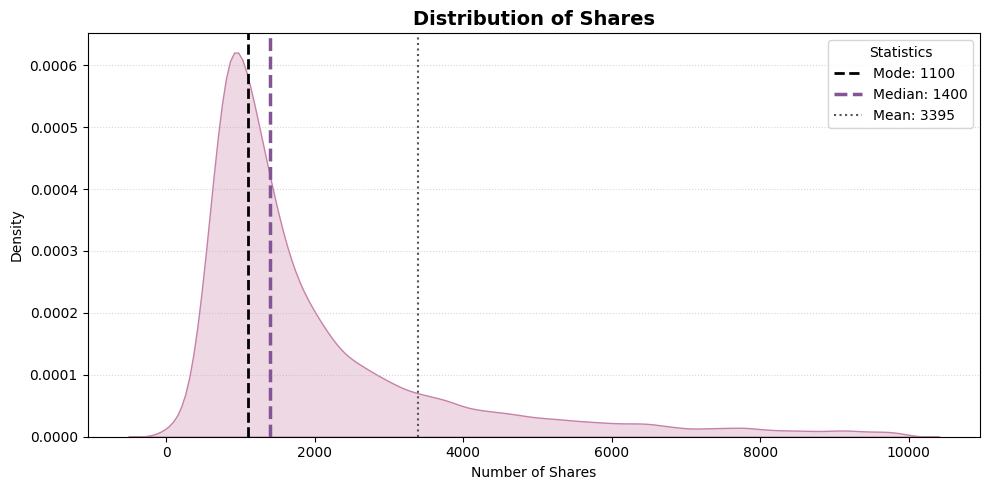

In [10]:
# Visualization
# Compute exact statistics in PySpark

# Mean
mean_val = sdf.select(F.avg("shares")).collect()[0][0]

# Median (In Big Data, we use approximate percentile for massive speed gains)
median_val = sdf.select(F.expr("percentile_approx(shares, 0.5)")).collect()[0][0]

# Mode (Group by shares, count them, sort descending, and take the top 1)
mode_row = sdf.groupBy("shares").count().orderBy(F.desc("count")).first()
mode_val = mode_row["shares"]

print(f"Calculated Stats -> Mean: {mean_val:.0f} | Median: {median_val:.0f} | Mode: {mode_val:.0f}")

# Filter and convert to Pandas for Plotting

# Filter out extreme values and pull ONLY the 'shares' column into Pandas
filtered_pdf = sdf.filter(F.col("shares") < 10000).select("shares").toPandas()

# Your exact plotting code

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the KDE using the Pandas series we just created
sns.kdeplot(filtered_pdf['shares'], color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)

# Add the vertical lines using the PySpark-calculated stats
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')

ax.set_title("Distribution of Shares", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Shares")
ax.set_ylabel("Density")
ax.set_facecolor('white')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(title="Statistics")

plt.tight_layout()
plt.show()

### Conver to Binary Classification Task

In [11]:
# Consider median as threshold
THRESHOLD = int(median_val)
print(f"Median shares: {THRESHOLD}")

# Convert target into a binary label and drop 'shares'
sdf = sdf.withColumn("label", (F.col("shares") > THRESHOLD).cast("integer")) # PySpark creates True/False, and .cast("integer") turns them into 1/0
sdf = sdf.drop("shares")

# Calculate and print class distribution
total = sdf.count()

# Group by the new label and count the rows for each class
counts_sdf = sdf.groupBy("label").count().collect()

# Convert the PySpark result rows into a standard Python dictionary
counts = {row['label']: row['count'] for row in counts_sdf}

print(f"\nClass distribution:")
print(f"Popular(1): {counts.get(1, 0)} ({counts.get(1, 0)/total:.2%})")
print(f"Unpopular(0): {counts.get(0, 0)} ({counts.get(0, 0)/total:.2%})")

Median shares: 1400

Class distribution:
Popular(1): 19562 (49.34%)
Unpopular(0): 20082 (50.66%)


   label  count
0      0  20082
1      1  19562


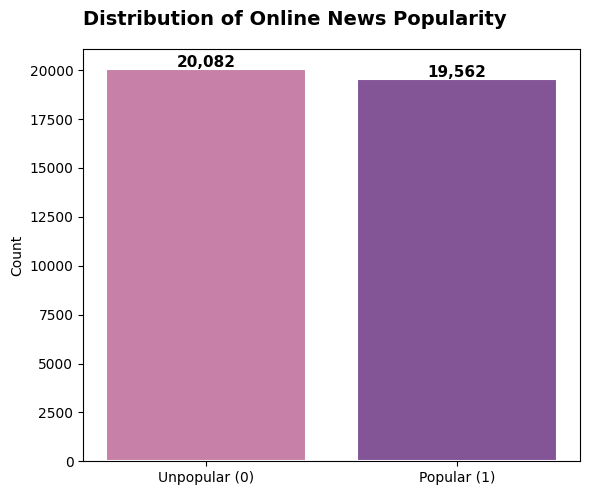

In [12]:
# Compute in PySpark (The MapReduce step)

# Ask the cluster to group the 1s and 0s, count them, and sort them so 0 is first.
# Since the result is only 2 rows, it is 100% safe to use .toPandas() immediately!
counts_pdf = sdf.groupBy("label").count().orderBy("label").toPandas()

# Let's print it just to verify it worked
print(counts_pdf)

# Plot locally with Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Distribution of Online News Popularity", fontsize=14, fontweight="bold")

# We use counts_pdf["count"] to feed the exact numbers to the bars
bars = ax.bar(["Unpopular (0)", "Popular (1)"], counts_pdf["count"], color=["#C781A8", "#835496"], edgecolor="white", linewidth=1.5)

for bar, v in zip(bars, counts_pdf["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Top 5 selected features: ['kw_avg_avg', 'LDA_02', 'data_channel_is_world', 'is_weekend', 'data_channel_is_entertainment']


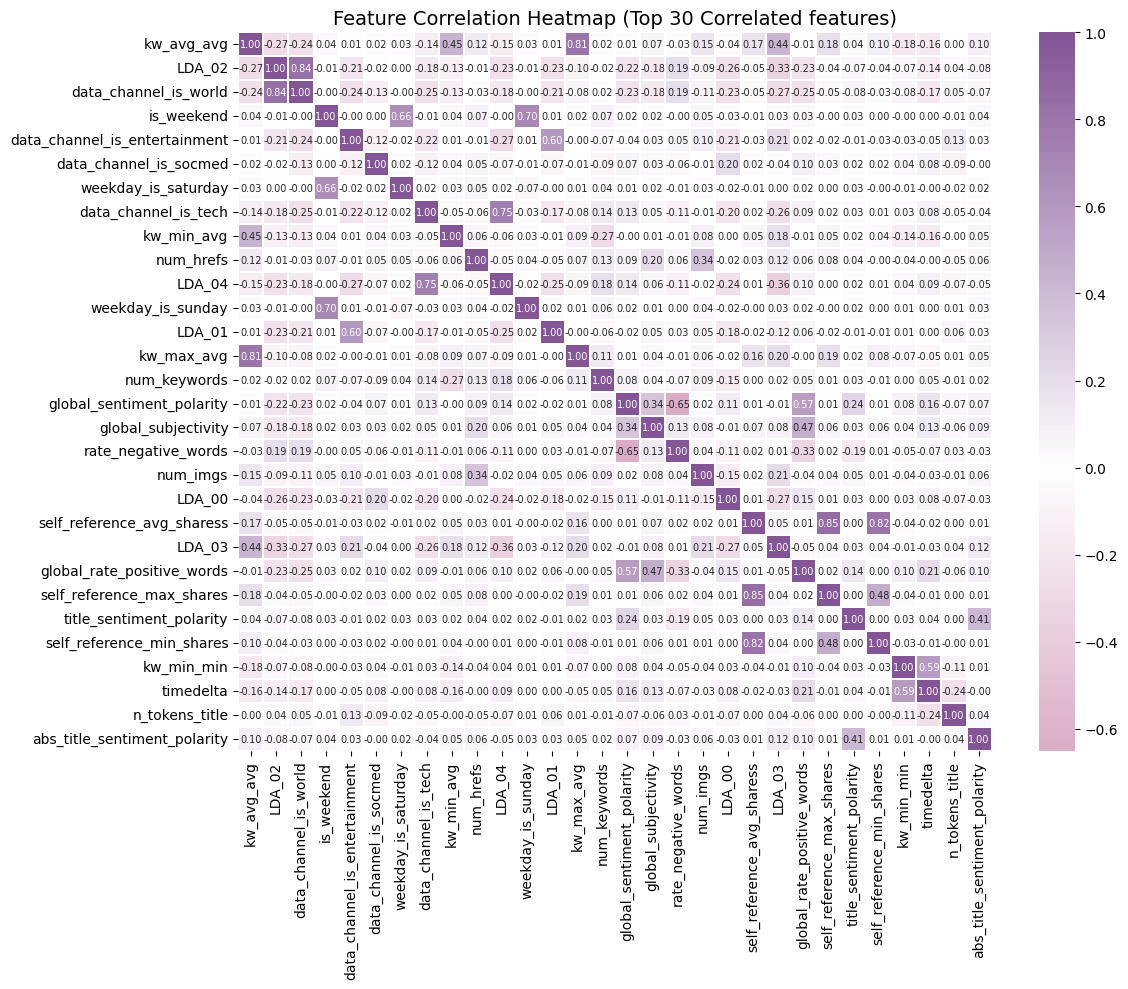

In [13]:
# ==========================================
# STEP 1: Feature-to-Target Correlation
# ==========================================
# Get all feature columns (Make sure to exclude 'label' and 'url')
feature_list = [c for c in sdf.columns if c not in ["label", "url", "original_shares"]]

# Calculate absolute correlation with the target label
corr_results = []
for feature in feature_list:
    # sdf.stat.corr is PySpark's built-in mathematical correlation function
    corr_value = sdf.stat.corr(feature, "label")

    # Save the absolute value (ignoring NaNs if they exist)
    if corr_value is not None:
        corr_results.append((feature, abs(corr_value)))

# Sort the results from highest to lowest and grab the names of the Top 30
corr_results.sort(key=lambda x: x[1], reverse=True)
top30_features = [x[0] for x in corr_results[:30]]

print(f"Top 5 selected features: {top30_features[:5]}")

# ==========================================
# STEP 2: Feature-to-Feature Correlation Matrix
# ==========================================
# To get a matrix in PySpark, we MUST pack the columns into a Vector first!
assembler = VectorAssembler(inputCols=top30_features, outputCol="top30_vectors")
sdf_vector = assembler.transform(sdf).select("top30_vectors")

# Calculate the Pearson correlation matrix on the cluster
matrix_row = Correlation.corr(sdf_vector, "top30_vectors").head()

# Extract the raw numbers (DenseMatrix) and convert it straight into a Pandas DataFrame
corr_matrix_array = matrix_row[0].toArray()
sub_corr_pdf = pd.DataFrame(corr_matrix_array, index=top30_features, columns=top30_features)

# ==========================================
# STEP 3: Plot Locally using Pandas
# ==========================================
# Your exact plotting code, untouched!
colors_cmap = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

plt.figure(figsize=(12, 10))
# Notice we pass the Pandas DataFrame (sub_corr_pdf) into Seaborn here
sns.heatmap(sub_corr_pdf, cmap=cmap, center=0, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap (Top 30 Correlated features)", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:


# ==========================================
# 1. Compute on the Cluster (PySpark)
# ==========================================

# First, get a list of all numeric columns so we don't try to average strings (like URLs)
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, T.NumericType)]
if 'label' in numeric_cols:
    numeric_cols.remove('label')

# Tell PySpark to calculate the average for every numeric column
agg_exprs = [F.avg(col).alias(col) for col in numeric_cols]

# Group by the label and aggregate.
# This runs across all your cores and returns exactly TWO rows!
avg_df = df.groupBy('label').agg(*agg_exprs)

# Bring those two rows into local memory as a Pandas DataFrame
pdf_avgs = avg_df.toPandas()


# ==========================================
# 2. Math & Plotting Locally (Pandas/Matplotlib)
# ==========================================

# Extract the two rows into the format your math expects
unpopular_mean = pdf_avgs[pdf_avgs['label'] == 0].drop(columns=['label']).iloc[0]
popular_mean   = pdf_avgs[pdf_avgs['label'] == 1].drop(columns=['label']).iloc[0]

# --- THE REST IS YOUR EXACT CODE ---

class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean,
                           'Mean_Popular':   popular_mean})

class_diff['Diff (%)'] = (
    (class_diff['Mean_Popular'] - class_diff['Mean_Unpopular'])
    / class_diff['Mean_Unpopular'].replace(0, np.nan)
) * 100

class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()

top30_diff  = class_diff.sort_values('Abs_Diff', ascending=False).head(59)
colors_diff = np.where(top30_diff['Diff (%)'] > 0, '#835496', '#C781A8')

plt.figure(figsize=(12, 10))
top30_diff['Diff (%)'].plot(kind='barh', color=colors_diff)

plt.title('Top 30 Features: Relative Difference Popular vs Unpopular',
          fontsize=13, fontweight='bold')
plt.xlabel('Difference (%)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()

purple_patch = mpatches.Patch(color='#C781A8', label='Higher in unpopular')
pink_patch = mpatches.Patch(color='#835496', label='Higher in popular')
plt.legend(handles=[purple_patch, pink_patch])

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

Top 5 selected features (by Diff %): ['data_channel_is_socmed', 'weekday_is_saturday', 'is_weekend', 'weekday_is_sunday', 'self_reference_min_shares']


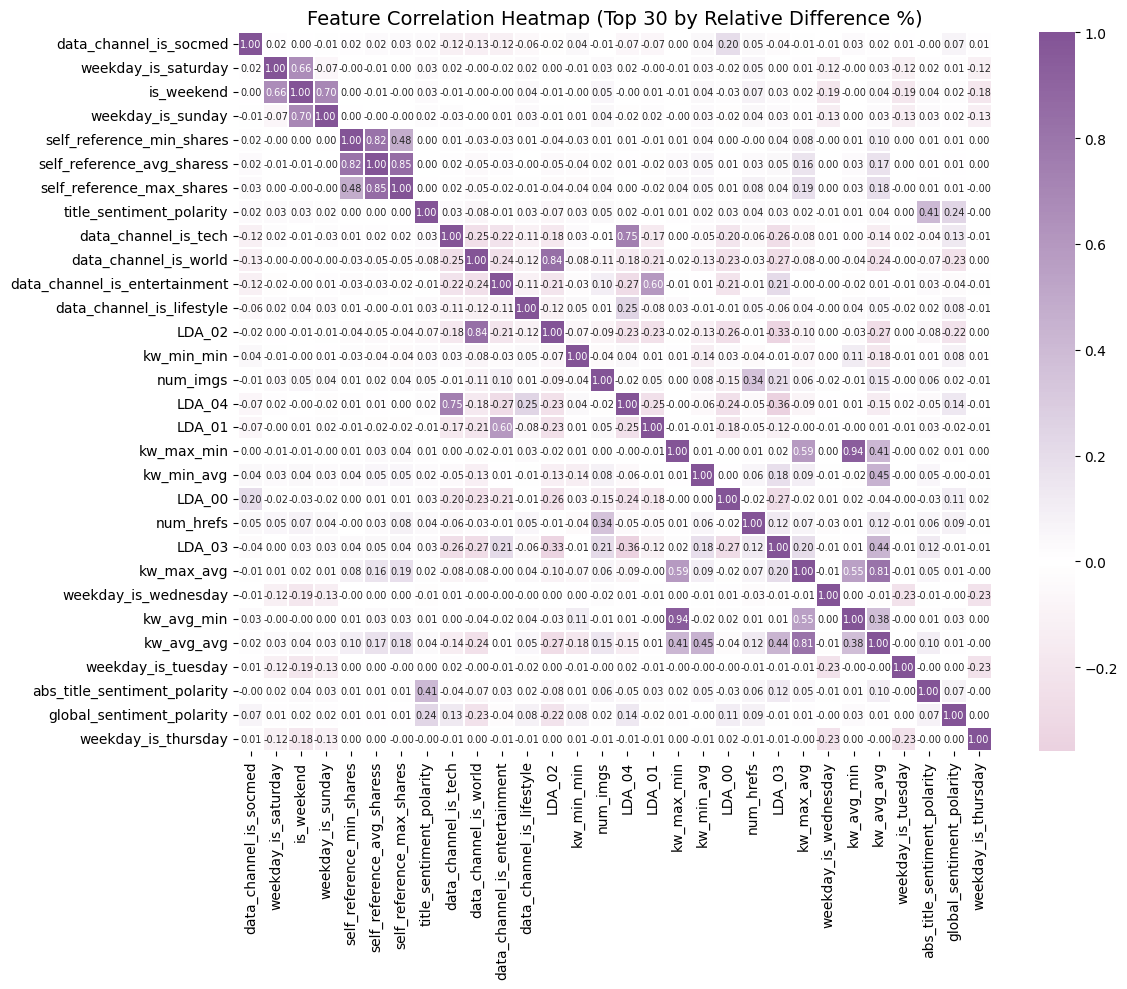

In [ ]:


# ==========================================
# STEP 1: Feature Selection via Diff (%)
# ==========================================
# Get all numeric columns, explicitly dropping our label and any saved targets
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, T.NumericType)]
for col_to_remove in ['label', 'original_shares', 'url']:
    if col_to_remove in numeric_cols:
        numeric_cols.remove(col_to_remove)

# 1a. Compute exact averages across the distributed cluster
agg_exprs = [F.avg(col).alias(col) for col in numeric_cols]
avg_df = df.groupBy('label').agg(*agg_exprs).toPandas()

# 1b. Calculate the Diff (%) locally in Pandas
unpopular_mean = avg_df[avg_df['label'] == 0].drop(columns=['label']).iloc[0]
popular_mean   = avg_df[avg_df['label'] == 1].drop(columns=['label']).iloc[0]

class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean, 'Mean_Popular': popular_mean})
class_diff['Diff (%)'] = ((class_diff['Mean_Popular'] - class_diff['Mean_Unpopular']) / class_diff['Mean_Unpopular'].replace(0, np.nan)) * 100
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()

# 1c. Extract the exact names of the Top 30 features by absolute difference
top30_features = class_diff.sort_values('Abs_Diff', ascending=False).head(30).index.tolist()

print(f"Top 5 selected features (by Diff %): {top30_features[:5]}")

# ==========================================
# STEP 2: Feature-to-Feature Correlation Matrix
# ==========================================
# Pack ONLY those Top 30 features into a Vector
assembler = VectorAssembler(inputCols=top30_features, outputCol="top30_vectors")
df_vector = assembler.transform(df).select("top30_vectors")

# Compute the correlation matrix on the Spark cluster
matrix_row = Correlation.corr(df_vector, "top30_vectors").head()

# Extract the array and convert to a Pandas DataFrame
corr_matrix_array = matrix_row[0].toArray()
sub_corr_pdf = pd.DataFrame(corr_matrix_array, index=top30_features, columns=top30_features)

# ==========================================
# STEP 3: Plot Locally using Pandas
# ==========================================
colors_cmap = ["#C781A8", "#FFFFFF", "#835496"]
cmap = LinearSegmentedColormap.from_list("custom", colors_cmap)

plt.figure(figsize=(12, 10))
sns.heatmap(sub_corr_pdf, cmap=cmap, center=0, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap (Top 30 by Relative Difference %)", fontsize=14)
plt.tight_layout()
plt.show()

### Feature Engineering

In [18]:
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [19]:
exclude_cols = ["timedelta", "label"]
feature_cols = [col for col in sdf.columns if col not in exclude_cols]

print(f"The number of feature columns: {len(feature_cols)}")

# Assemble features into a single vector without scailing
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_sdf = assembler.transform(sdf)
prepared_sdf = assembled_sdf.select("timedelta", "features", "label")

print(f"The number of data: {prepared_sdf.count()}")
prepared_sdf.show(7)

The number of feature columns: 58
The number of data: 39644
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 7 rows


## Rolling Window

In [20]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Iterator

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pyspark.sql import DataFrame, Window
from pyspark.sql.functions import when, col, row_number
from dataclasses import dataclass, field
from pyspark.sql import DataFrame
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number
from pyspark.ml.feature import StandardScaler

In [21]:
# Dataclasses
@dataclass
class FoldSplit:
    fold_index: int
    train: DataFrame
    eval: DataFrame
    test: DataFrame
    tr_start: int
    tr_end: int
    ev_start: int
    ev_end: int
    te_start: int
    te_end: int
    n_train: int
    n_eval: int
    n_test: int

@dataclass
class WindowConfig:
    initial_train_size: int = 15_150
    step_size: int = 3_000
    num_folds: int = 6
    train_frac: float = 0.70
    time_col: str = "timedelta"
    row_col: str = "row_num"
    scale_features: bool = True
    verbose: bool = True

# Leakage-safe scaling
# Leakage-safe scaling
def scale_fold(train_df: DataFrame, eval_df: DataFrame, test_df: DataFrame, features_col: str = "features"):
    scaler = StandardScaler(inputCol=features_col, outputCol="scaled_features", withMean=True, withStd=True)

    # 1. ADD CACHE HERE: Lock the filtered training data in memory
    # before PySpark runs the .fit() action
    train_df.cache()

    # Fit ONLY on training data
    scaler_model = scaler.fit(train_df)

    train_scaled = (scaler_model.transform(train_df).drop(features_col).withColumnRenamed("scaled_features", features_col))
    eval_scaled = (scaler_model.transform(eval_df).drop(features_col).withColumnRenamed("scaled_features", features_col))
    test_scaled = (scaler_model.transform(test_df).drop(features_col).withColumnRenamed("scaled_features", features_col))

    return train_scaled, eval_scaled, test_scaled

# Core function
def expanding_window_splits(df: DataFrame, cfg: WindowConfig | None = None, **kwargs) -> list[FoldSplit]:

    if cfg is None:
        cfg = WindowConfig(**kwargs)

    # chronological ordering : ascending = oldest -> newest
    window_spec = Window.orderBy(col(cfg.time_col).asc())
    sdf_ordered = (df.withColumn(cfg.row_col,row_number().over(window_spec) - 1).cache())

    total_rows = sdf_ordered.count()

    if cfg.verbose:
        _print_header(cfg)

    splits: list[FoldSplit] = []

    # Build folds
    for i in range(cfg.num_folds):
        # Expanding train/eval boundary
        W = cfg.initial_train_size + (i * cfg.step_size)

        train_size = int(W * cfg.train_frac)
        eval_size = W - train_size

        # indices
        tr_start = 0
        tr_end = train_size - 1

        ev_start = train_size
        ev_end = W - 1

        te_start = W
        te_end = min(W + cfg.step_size - 1, total_rows - 1)

        # Stop if no test data remains
        if te_start >= total_rows:
            break

        # Lazy filtering
        train_fold = sdf_ordered.filter(col(cfg.row_col).between(tr_start, tr_end))
        eval_fold = sdf_ordered.filter(col(cfg.row_col).between(ev_start, ev_end))
        test_fold = sdf_ordered.filter(col(cfg.row_col).between(te_start, te_end))

        # Leakage-safe scaling
        if cfg.scale_features:
            train_fold, eval_fold, test_fold = scale_fold(train_fold, eval_fold, test_fold)


        # 2. ADD CACHE HERE: Lock the final processed folds in memory
        train_fold.cache()
        eval_fold.cache()
        test_fold.cache()

        train_fold.cache().count()
        eval_fold.cache().count()
        test_fold.cache().count()

        # Deterministic counts
        # No Spark count() actions needed
        n_train = tr_end - tr_start + 1
        n_eval = ev_end - ev_start + 1
        n_test = te_end - te_start + 1

        fold = FoldSplit(
            fold_index=i + 1,

            train=train_fold,
            eval=eval_fold,
            test=test_fold,

            tr_start=tr_start,
            tr_end=tr_end,

            ev_start=ev_start,
            ev_end=ev_end,

            te_start=te_start,
            te_end=te_end,

            n_train=n_train,
            n_eval=n_eval,
            n_test=n_test
        )

        splits.append(fold)

        if cfg.verbose:
            _print_fold(fold)

    return splits

# Print helpers
def _print_header(cfg: WindowConfig):

    print("\nWindow Parameters")
    print(f"Initial train size : {cfg.initial_train_size:,}")
    print(f"Step size          : {cfg.step_size:,}")
    print(f"Number of folds    : {cfg.num_folds}")
    print(f"Train fraction     : {cfg.train_frac:.0%}")
    print(f"Scaling            : {cfg.scale_features}")

    print("\n" + "─" * 110)

    print(
        f"{'Fold':>4} "
        f"{'Train':>18} "
        f"{'Eval':>18} "
        f"{'Test':>18} "
        f"{'n_train':>10} "
        f"{'n_eval':>10} "
        f"{'n_test':>10}"
    )

    print("─" * 110)


def _print_fold(fold: FoldSplit):

    print(
        f"{fold.fold_index:>4} "
        f"{f'{fold.tr_start:,}-{fold.tr_end:,}':>18} "
        f"{f'{fold.ev_start:,}-{fold.ev_end:,}':>18} "
        f"{f'{fold.te_start:,}-{fold.te_end:,}':>18} "
        f"{fold.n_train:>10,} "
        f"{fold.n_eval:>10,} "
        f"{fold.n_test:>10,}"
    )

In [22]:
cfg = WindowConfig(
    initial_train_size=15_150,
    step_size=3_000,
    num_folds=6,
    train_frac=0.70,
    time_col="timedelta",
    scale_features=True,
    verbose=True
    )

splits = expanding_window_splits(prepared_sdf, cfg)


Window Parameters
Initial train size : 15,150
Step size          : 3,000
Number of folds    : 6
Train fraction     : 70%
Scaling            : True

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fold              Train               Eval               Test    n_train     n_eval     n_test
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1           0-10,604      10,605-15,149      15,150-18,149     10,605      4,545      3,000
   2           0-12,704      12,705-18,149      18,150-21,149     12,705      5,445      3,000
   3           0-14,803      14,804-21,149      21,150-24,149     14,804      6,346      3,000
   4           0-16,904      16,905-24,149      24,150-27,149     16,905      7,245      3,000
   5           0-19,004      19,005-27,149      27,150-30,149     19,005      8,145      3,000
   6           0-21,104      21,105-30,149      30,150-33,1

In [23]:
# Visualisation

# Colours
SPLIT_COLOURS = {
    "Train": "#2E86AB",
    "Eval":  "#F6AE2D",
    "Test":  "#E84855",
}

def plot_splits(splits: list[FoldSplit], cfg: WindowConfig):
    n = len(splits)
    if n == 0:
        raise ValueError("splits list is empty — nothing to plot.")

    fig_h = max(4, n * 0.9)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for fold in splits:
        y = fold.fold_index - 1  # 0-based y position

        # Each bar: (start, width) — metadata avoids any Spark action
        segments = [
            ("Train", fold.tr_start, fold.tr_end - fold.tr_start),
            ("Eval",  fold.ev_start, fold.ev_end - fold.ev_start),
            ("Test",  fold.te_start, fold.te_end - fold.te_start),
        ]

        for label, left, width in segments:
            ax.barh(
                y, width, left=left,
                height=0.6,
                color=SPLIT_COLOURS[label],
                edgecolor="white",
                linewidth=0.4,
            )

            # Annotate size inside the bar when wide enough
            if width > 300:
                ax.text(left + width / 2, y, f"{width:,}", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

    # Axes cosmetics
    ax.set_yticks(range(n))
    ax.set_yticklabels([f"Fold {f.fold_index}" for f in splits], fontsize=9)
    ax.invert_yaxis()   # fold 1 at top

    ax.set_xlabel("Row index  (oldest → newest publication date)", fontsize=10)
    ax.grid(axis="x", linestyle=":", alpha=0.35, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)

    # Title
    last = splits[-1]
    W_last = last.te_end + 1
    train_sz = last.tr_end - last.tr_start + 1
    eval_sz = last.ev_end - last.ev_start + 1

    title = (
        f"Rolling-Window Time-Series Split\n"
        f"W={W_last:,}  (Train={train_sz:,} + Eval={eval_sz:,})   "
        f"L={cfg.step_size:,}   Folds={n}"
        )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)

    # Legend
    patches = [mpatches.Patch(color=SPLIT_COLOURS[k], label=k) for k in ("Train", "Eval", "Test")]
    ax.legend(handles=patches, loc="lower right", fontsize=10, framealpha=0.85)

    plt.tight_layout()
    plt.show()

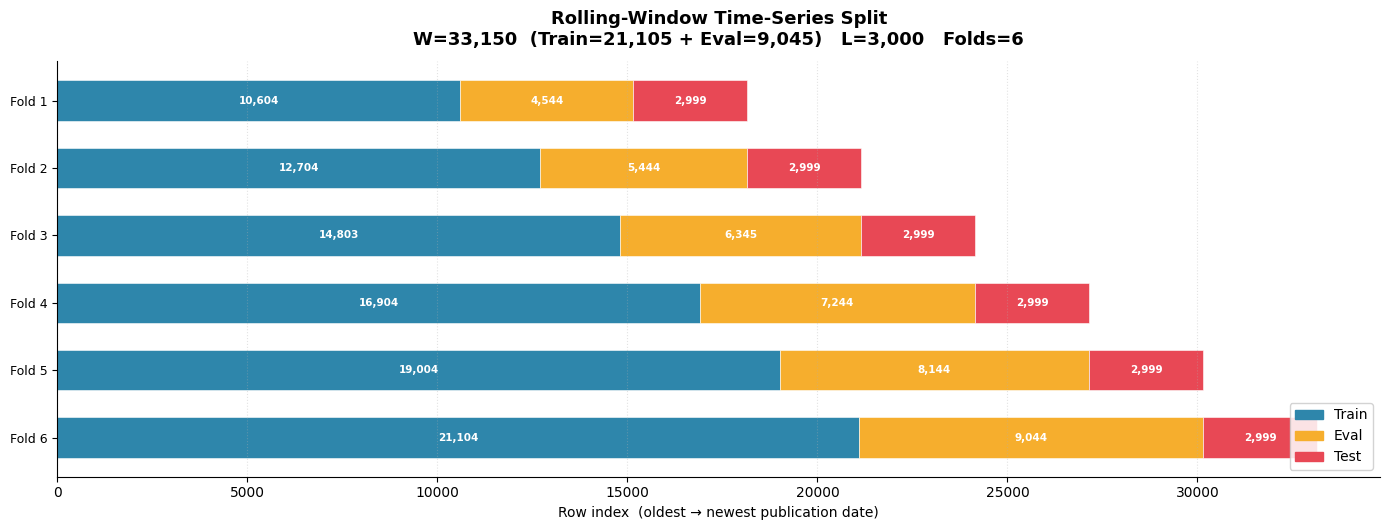

In [24]:
# Visualise window splits
plot_splits(splits, cfg)

In [25]:
from dataclasses import dataclass
from pyspark.sql import DataFrame
# Dataclass
@dataclass
class FoldBalance:

    fold_index: int
    split: str

    count_0: int
    count_1: int

    pct_positive: float
    global_positive: float
    drift: float

    balanced: bool

    @property
    def total(self) -> int:
        return self.count_0 + self.count_1

    @property
    def status(self) -> str:
        return "✔" if self.balanced else "⚠ drift"

# Helper
def _balance_for_df(df: DataFrame) -> tuple[int, int]:
    """
    Return (count_0, count_1)
    Assumes binary labels {0,1}.
    """

    rows = df.groupBy("label").count().collect()

    count_0 = next(
        (r["count"] for r in rows if r["label"] == 0),
        0
    )

    count_1 = next(
        (r["count"] for r in rows if r["label"] == 1),
        0
    )

    return count_0, count_1


# ==========================================================
# Main function
# ==========================================================
def check_class_balance(splits: list[FoldSplit], full_df: DataFrame,tolerance: float = 5.0
):

    # ------------------------------------------------------
    # Global dataset distribution
    # ------------------------------------------------------
    global_c0, global_c1 = _balance_for_df(full_df)

    global_total = global_c0 + global_c1

    global_positive = (
        global_c1 / global_total * 100
        if global_total > 0
        else 0.0
    )

    print("\nGlobal dataset distribution:")
    print(
        f"Class 0: {global_c0:,} | "
        f"Class 1: {global_c1:,} | "
        f"Positive rate: {global_positive:.1f}%"
    )

    print("\nClass distribution drift per fold:")
    print(
        f"{'Fold':>4}  "
        f"{'Split':>6}  "
        f"{'Class 0':>8}  "
        f"{'Class 1':>8}  "
        f"{'% Positive':>12}  "
        f"{'Drift':>8}  "
        f"{'Status':>10}"
    )

    print("-" * 80)

    split_map = {
        "train": lambda f: ("train", f.train),
        "eval": lambda f: ("eval", f.eval),
        "test": lambda f: ("test", f.test),
    }

    keys = ["train", "eval", "test"]

    results: list[FoldBalance] = []

    # ------------------------------------------------------
    # Check every fold + split
    # ------------------------------------------------------
    for fold in splits:

        for key in keys:

            split_name, df = split_map[key](fold)

            c0, c1 = _balance_for_df(df)

            total = c0 + c1

            pct_positive = (
                c1 / total * 100
                if total > 0
                else 0.0
            )

            drift = pct_positive - global_positive

            balanced = abs(drift) <= tolerance

            fb = FoldBalance(
                fold_index=fold.fold_index,
                split=split_name,

                count_0=c0,
                count_1=c1,

                pct_positive=pct_positive,
                global_positive=global_positive,
                drift=drift,

                balanced=balanced
            )

            results.append(fb)

            print(
                f"{fold.fold_index:>4}  "
                f"{split_name:>6}  "
                f"{c0:>8,}  "
                f"{c1:>8,}  "
                f"{pct_positive:>11.1f}%  "
                f"{drift:>+7.1f}%  "
                f"{fb.status:>10}"
            )

    # ------------------------------------------------------
    # Summary
    # ------------------------------------------------------
    n_bad = sum(
        1 for r in results
        if not r.balanced
    )

    if n_bad == 0:
        print(
            f"\nAll fold distributions are stable "
            f"(within ±{tolerance:.1f}%) ✔"
        )
    else:
        print(
            f"\n⚠ {n_bad} split(s) exceed "
            f"±{tolerance:.1f}% drift."
        )

    return results

In [26]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Iterator

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pyspark.sql import DataFrame
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number
from pyspark.ml.feature import StandardScaler


# ──────────────────────────────────────────────────────────
# Dataclasses
# ──────────────────────────────────────────────────────────
@dataclass
class FoldSplit:
    fold_index: int
    train: DataFrame
    eval: DataFrame
    test: DataFrame
    tr_start: int
    tr_end: int
    ev_start: int
    ev_end: int
    te_start: int
    te_end: int
    n_train: int
    n_eval: int
    n_test: int


@dataclass
class WindowConfig:
    initial_train_size: int = 15_150
    step_size: int = 3_000
    num_folds: int = 6
    train_frac: float = 0.70
    time_col: str = "timedelta"
    row_col: str = "row_num"
    scale_features: bool = True
    verbose: bool = True


# ──────────────────────────────────────────────────────────
# FIX 1: Leakage-safe scaling — cache train ONCE, then unpersist
# ──────────────────────────────────────────────────────────
def scale_fold(
    train_df: DataFrame,
    eval_df: DataFrame,
    test_df: DataFrame,
    features_col: str = "features",
):
    scaler = StandardScaler(
        inputCol=features_col,
        outputCol="scaled_features",
        withMean=True,
        withStd=True,
    )

    # Cache train before .fit() so Spark doesn't recompute it
    # for every parameter in the scaler internals
    train_df = train_df.cache()
    train_df.count()  # materialise the cache

    scaler_model = scaler.fit(train_df)

    train_scaled = (
        scaler_model.transform(train_df)
        .drop(features_col)
        .withColumnRenamed("scaled_features", features_col)
    )
    eval_scaled = (
        scaler_model.transform(eval_df)
        .drop(features_col)
        .withColumnRenamed("scaled_features", features_col)
    )
    test_scaled = (
        scaler_model.transform(test_df)
        .drop(features_col)
        .withColumnRenamed("scaled_features", features_col)
    )

    # FIX: materialise scaled folds so downstream fits don't re-trigger
    # the scaler lineage; then free the raw train from cache
    train_scaled = train_scaled.cache()
    eval_scaled  = eval_scaled.cache()
    test_scaled  = test_scaled.cache()

    train_scaled.count()
    eval_scaled.count()
    test_scaled.count()

    train_df.unpersist()   # raw (unscaled) train no longer needed

    return train_scaled, eval_scaled, test_scaled


# ──────────────────────────────────────────────────────────
# FIX 2: expanding_window_splits — single cache of sdf_ordered,
#         no duplicate .cache() calls, correct unpersist at fold end
# ──────────────────────────────────────────────────────────
def expanding_window_splits(
    df: DataFrame,
    cfg: WindowConfig | None = None,
    **kwargs,
) -> list[FoldSplit]:

    if cfg is None:
        cfg = WindowConfig(**kwargs)

    # Sort chronologically (oldest → newest) and add a row index
    window_spec = Window.orderBy(col(cfg.time_col).asc())
    sdf_ordered = (
        df.withColumn(cfg.row_col, row_number().over(window_spec) - 1)
        .cache()       # cache ONCE here; materialise immediately
    )
    sdf_ordered.count()

    total_rows = sdf_ordered.count()

    if cfg.verbose:
        _print_header(cfg)

    splits: list[FoldSplit] = []
    # Track folds from the previous iteration so we can unpersist them
    # after the next fold's data has been cached (avoids evicting data
    # we still need while building the next fold).
    prev_folds = []

    for i in range(cfg.num_folds):

        # Expanding train/eval boundary
        W          = cfg.initial_train_size + (i * cfg.step_size)
        train_size = int(W * cfg.train_frac)
        eval_size  = W - train_size

        tr_start = 0
        tr_end   = train_size - 1

        ev_start = train_size
        ev_end   = W - 1

        te_start = W
        te_end   = min(W + cfg.step_size - 1, total_rows - 1)

        if te_start >= total_rows:
            break

        # Lazy filter (no Spark action yet)
        train_fold = sdf_ordered.filter(col(cfg.row_col).between(tr_start, tr_end))
        eval_fold  = sdf_ordered.filter(col(cfg.row_col).between(ev_start, ev_end))
        test_fold  = sdf_ordered.filter(col(cfg.row_col).between(te_start, te_end))

        # Scale (materialises + caches inside scale_fold)
        if cfg.scale_features:
            train_fold, eval_fold, test_fold = scale_fold(train_fold, eval_fold, test_fold)

        # Deterministic sizes — no extra Spark actions needed
        n_train = tr_end - tr_start + 1
        n_eval  = ev_end - ev_start + 1
        n_test  = te_end - te_start + 1

        fold = FoldSplit(
            fold_index=i + 1,
            train=train_fold, eval=eval_fold, test=test_fold,
            tr_start=tr_start, tr_end=tr_end,
            ev_start=ev_start, ev_end=ev_end,
            te_start=te_start, te_end=te_end,
            n_train=n_train, n_eval=n_eval, n_test=n_test,
        )

        splits.append(fold)

        # Unpersist the *previous* fold's data now that the current
        # fold is safely cached — keeps memory usage flat
        for old_df in prev_folds:
            old_df.unpersist()
        prev_folds = [train_fold, eval_fold, test_fold]

        if cfg.verbose:
            _print_fold(fold)

    return splits


# ──────────────────────────────────────────────────────────
# Print helpers (unchanged)
# ──────────────────────────────────────────────────────────
def _print_header(cfg: WindowConfig):
    print("\nWindow Parameters")
    print(f"Initial train size : {cfg.initial_train_size:,}")
    print(f"Step size          : {cfg.step_size:,}")
    print(f"Number of folds    : {cfg.num_folds}")
    print(f"Train fraction     : {cfg.train_frac:.0%}")
    print(f"Scaling            : {cfg.scale_features}")
    print("\n" + "─" * 110)
    print(
        f"{'Fold':>4} "
        f"{'Train':>18} "
        f"{'Eval':>18} "
        f"{'Test':>18} "
        f"{'n_train':>10} "
        f"{'n_eval':>10} "
        f"{'n_test':>10}"
    )
    print("─" * 110)


def _print_fold(fold: FoldSplit):
    print(
        f"{fold.fold_index:>4} "
        f"{f'{fold.tr_start:,}-{fold.tr_end:,}':>18} "
        f"{f'{fold.ev_start:,}-{fold.ev_end:,}':>18} "
        f"{f'{fold.te_start:,}-{fold.te_end:,}':>18} "
        f"{fold.n_train:>10,} "
        f"{fold.n_eval:>10,} "
        f"{fold.n_test:>10,}"
    )


## Model defining

In [27]:
from pyspark.ml.classification import (
    RandomForestClassifier,
    GBTClassifier,
    LogisticRegression,
)
from pyspark.ml.tuning import ParamGridBuilder

# ======================================================
# Logistic Regression  — 3 × 2 = 6 combinations
# ======================================================
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    standardization=True,
    tol=1e-6,
)

lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build()
)

# ======================================================
# Random Forest  — 2 × 2 × 2 = 8 combinations
# FIX: removed numTrees=200, maxDepth=15, minInstancesPerNode grid
#      (24 combos → 8 combos; each RF fit is expensive)
# ======================================================
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42,
)

rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees,              [50, 100])
    .addGrid(rf.maxDepth,              [5, 10])
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
    .build()
)

# ======================================================
# GBT  — 2 × 2 × 2 = 8 combinations
# FIX: removed maxDepth=7, stepSize=0.03, maxIter=100
#      (18 combos → 8 combos; GBT is the costliest model)
# ======================================================
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42,
)

gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .addGrid(gbt.maxIter,  [50, 100])
    .build()
)

model_configs = [
    ("Logistic Regression",   lr,  lr_grid),
    ("Random Forest",         rf,  rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
]

print("Model configs ready.")
for name, _, grid in model_configs:
    print(f"  {name}: {len(grid)} combinations")


Model configs ready.
  Logistic Regression: 6 combinations
  Random Forest: 8 combinations
  Gradient Boosted Tree: 8 combinations


## Helper Function

In [28]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import functions as F
from pyspark.ml.tuning import TrainValidationSplit

In [29]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics


def compute_metrics(predictions):

    roc_eval = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    pr_eval = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderPR"
    )

    preds_rdd = (
        predictions
        .select("prediction", "label")
        .rdd
        .map(lambda r: (float(r.prediction), float(r.label)))
    )

    metrics = MulticlassMetrics(preds_rdd)

    return {
        "accuracy": metrics.accuracy,
        "f1": metrics.fMeasure(1.0),
        "precision": metrics.precision(1.0),
        "recall": metrics.recall(1.0),
        "auc_roc": roc_eval.evaluate(predictions),
        "auc_pr": pr_eval.evaluate(predictions),
    }

In [30]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics


def train_and_evaluate_temporal(
    model_name,
    estimator,
    param_grid,
    train_df,
    eval_df,
    test_df,
):
    """
    Manual hold-out hyperparameter search.

    FIX: The original version called model.fit(train_df) for EVERY param
    combination with no caching, causing Spark to recompute the full
    training lineage (including the scaler) on every iteration — this is
    what produced the infinite-loop / hang in Colab.

    Fixes applied:
      1. train_df and eval_df are checkpointed to cut the DAG before the
         loop, so Spark never re-executes the rolling-window + scaler
         lineage on each fit() call.
      2. The refit on full_train = train + eval also checkpoints to keep
         the final model's lineage short.
    """
    print(f"\n[{model_name}] tuning ({len(param_grid)} combinations)...")

    roc_eval = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC",
    )

    best_auc    = -1.0
    best_model  = None
    best_params = None

    # ──────────────────────────────────────────────────────
    # FIX: Persist train + eval before the loop so each
    #      .fit() call doesn't re-execute the entire DAG
    #      (rolling-window filter + scaler) from scratch.
    # ──────────────────────────────────────────────────────
    train_df = train_df.persist()
    eval_df  = eval_df.persist()
    # Materialise both so the first .fit() is not slower
    train_df.count()
    eval_df.count()

    # ── Hyperparameter search: train → fit, eval → score ──
    for param_map in param_grid:
        fitted = estimator.copy(param_map).fit(train_df)
        auc    = roc_eval.evaluate(fitted.transform(eval_df))

        if auc > best_auc:
            best_auc    = auc
            best_model  = estimator.copy(param_map)
            best_params = param_map

    print(f"[{model_name}] best eval ROC-AUC = {best_auc:.4f}")

    # Free the cached splits — we no longer need them separately
    train_df.unpersist()
    eval_df.unpersist()

    # ── Refit on TRAIN ∪ EVAL ─────────────────────────────
    full_train  = fold.train.union(fold.eval).persist()
    full_train.count()

    final_model = best_model.copy(best_params).fit(full_train)

    full_train.unpersist()

    # ── Evaluate on held-out TEST ─────────────────────────
    test_preds = final_model.transform(test_df)
    metrics    = compute_metrics(test_preds)

    print(
        f"[{model_name}] "
        f"ACC={metrics['accuracy']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"P={metrics['precision']:.4f} | "
        f"R={metrics['recall']:.4f} | "
        f"ROC-AUC={metrics['auc_roc']:.4f} | "
        f"PR-AUC={metrics['auc_pr']:.4f}"
    )

    return metrics, final_model, best_params


In [31]:
from collections import defaultdict

all_results     = defaultdict(dict)
all_models      = defaultdict(dict)
all_predictions = defaultdict(dict)
best_params_log = defaultdict(dict)

print("=" * 80)
print("TEMPORAL EXPANDING WINDOW TRAINING")
print("=" * 80)

for fold in splits:

    print("\n" + "—" * 80)
    print(f"FOLD {fold.fold_index}")
    print("—" * 80)

    for model_name, estimator, param_grid in model_configs:

        metrics, final_model, best_params = train_and_evaluate_temporal(
            model_name=model_name,
            estimator=estimator,
            param_grid=param_grid,
            train_df=fold.train,
            eval_df=fold.eval,
            test_df=fold.test,
        )

        all_results[fold.fold_index][model_name]     = metrics
        all_models[fold.fold_index][model_name]      = final_model
        best_params_log[fold.fold_index][model_name] = {
            p.name: v for p, v in best_params.items()
        }

        # FIX: store predictions for ROC plot (needed by cell 45)
        all_predictions[fold.fold_index][model_name] = (
            final_model.transform(fold.test)
        )

    # FIX: unpersist this fold's DataFrames after ALL models for this
    #      fold are done — keeps Spark's memory clean for the next fold
    fold.train.unpersist()
    fold.eval.unpersist()
    fold.test.unpersist()

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)


TEMPORAL EXPANDING WINDOW TRAINING

————————————————————————————————————————————————————————————————————————————————
FOLD 1
————————————————————————————————————————————————————————————————————————————————

[Logistic Regression] tuning (6 combinations)...
[Logistic Regression] best eval ROC-AUC = 0.7395


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


[Logistic Regression] ACC=0.6673 | F1=0.6801 | P=0.7116 | R=0.6513 | ROC-AUC=0.7197 | PR-AUC=0.7284

[Random Forest] tuning (8 combinations)...
[Random Forest] best eval ROC-AUC = 0.7445
[Random Forest] ACC=0.6680 | F1=0.6816 | P=0.7111 | R=0.6544 | ROC-AUC=0.7262 | PR-AUC=0.7411

[Gradient Boosted Tree] tuning (8 combinations)...
[Gradient Boosted Tree] best eval ROC-AUC = 0.7443
[Gradient Boosted Tree] ACC=0.6753 | F1=0.6926 | P=0.7128 | R=0.6734 | ROC-AUC=0.7356 | PR-AUC=0.7612

————————————————————————————————————————————————————————————————————————————————
FOLD 2
————————————————————————————————————————————————————————————————————————————————

[Logistic Regression] tuning (6 combinations)...
[Logistic Regression] best eval ROC-AUC = 0.7241
[Logistic Regression] ACC=0.6320 | F1=0.6607 | P=0.6350 | R=0.6887 | ROC-AUC=0.6821 | PR-AUC=0.6942

[Random Forest] tuning (8 combinations)...
[Random Forest] best eval ROC-AUC = 0.7304
[Random Forest] ACC=0.6493 | F1=0.6843 | P=0.6437 | R=0.73

In [32]:
import pandas as pd

def results_to_df(all_results):
    rows = []

    for fold_id, models in all_results.items():
        for model_name, metrics in models.items():
            rows.append({
                "fold": fold_id,
                "model": model_name,
                "auc": metrics["auc_roc"],
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
            })

    return pd.DataFrame(rows)


df_results = results_to_df(all_results)
df_results.head()

,fold,model,auc,accuracy,f1,precision,recall
0,1,Logistic Regression,0.719750,0.667333,0.680128,0.711603,0.651320
1,1,Random Forest,0.726237,0.668000,0.681586,0.711141,0.654389
2,1,Gradient Boosted Tree,0.735595,0.675333,0.692551,0.712801,0.673419
3,2,Logistic Regression,0.682078,0.632000,0.660725,0.634968,0.688661
4,2,Random Forest,0.707735,0.649333,0.684274,0.643704,0.730301


In [33]:
summary = (
    df_results
    .groupby("model")
    .agg({
        "auc": "mean",
        "accuracy": "mean",
        "f1": "mean",
        "precision": "mean",
        "recall": "mean"
    })
    .sort_values("auc", ascending=False)
)

print(summary)

                            auc  accuracy        f1  precision    recall
model                                                                   
Gradient Boosted Tree  0.713684  0.655667  0.645301   0.640509  0.652924
Random Forest          0.711437  0.655556  0.650704   0.637469  0.667878
Logistic Regression    0.689367  0.637444  0.638193   0.616619  0.665296


In [34]:
best_auc = summary["auc"].idxmax()
best_acc = summary["accuracy"].idxmax()
best_f1  = summary["f1"].idxmax()
best_pr  = summary["precision"].idxmax()
best_rc  = summary["recall"].idxmax()

print("\nBest AUC:", best_auc)
print("Best Accuracy:", best_acc)
print("Best F1:", best_f1)
print("Best Precision:", best_pr)
print("Best Recall:", best_rc)


Best AUC: Gradient Boosted Tree
Best Accuracy: Gradient Boosted Tree
Best F1: Random Forest
Best Precision: Gradient Boosted Tree
Best Recall: Random Forest


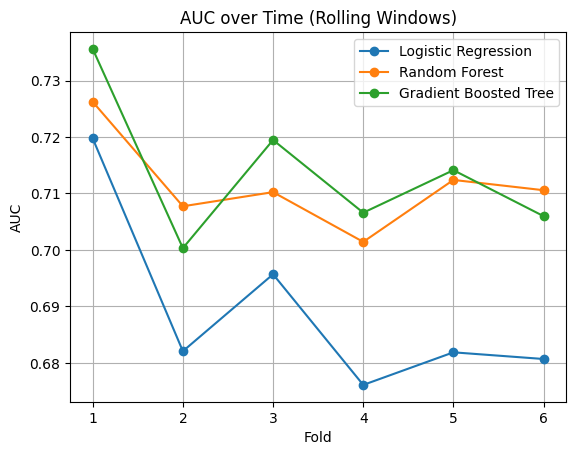

In [35]:
import matplotlib.pyplot as plt

def plot_performance_over_time(df_results):

    models = df_results["model"].unique()

    plt.figure()

    for m in models:
        temp = df_results[df_results["model"] == m].sort_values("fold")
        plt.plot(temp["fold"], temp["auc"], marker="o", label=m)

    plt.title("AUC over Time (Rolling Windows)")
    plt.xlabel("Fold")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid()
    plt.show()


plot_performance_over_time(df_results)

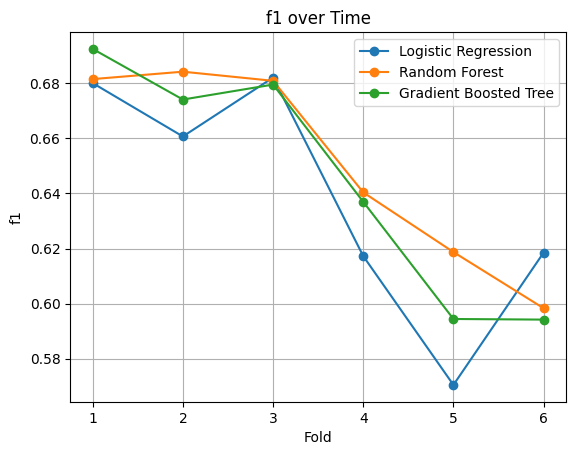

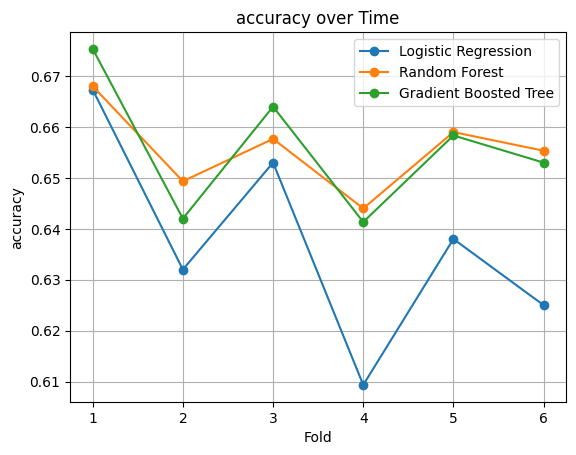

In [36]:
def plot_metric(df, metric):

    plt.figure()

    for m in df["model"].unique():
        temp = df[df["model"] == m].sort_values("fold")
        plt.plot(temp["fold"], temp[metric], marker="o", label=m)

    plt.title(f"{metric} over Time")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()


plot_metric(df_results, "f1")
plot_metric(df_results, "accuracy")

In [37]:
def show_best_params(best_params_log):

    for fold, models in best_params_log.items():

        print("\n" + "=" * 60)
        print(f"FOLD {fold}")
        print("=" * 60)

        for model, params in models.items():
            print(f"\n{model}:")
            for k, v in params.items():
                print(f"  {k}: {v}")


show_best_params(best_params_log)


FOLD 1

Logistic Regression:
  regParam: 0.01
  elasticNetParam: 0.0

Random Forest:
  numTrees: 100
  maxDepth: 10
  featureSubsetStrategy: sqrt

Gradient Boosted Tree:
  maxDepth: 3
  stepSize: 0.1
  maxIter: 100

FOLD 2

Logistic Regression:
  regParam: 0.01
  elasticNetParam: 0.0

Random Forest:
  numTrees: 100
  maxDepth: 10
  featureSubsetStrategy: sqrt

Gradient Boosted Tree:
  maxDepth: 3
  stepSize: 0.1
  maxIter: 100

FOLD 3

Logistic Regression:
  regParam: 0.01
  elasticNetParam: 0.0

Random Forest:
  numTrees: 100
  maxDepth: 10
  featureSubsetStrategy: sqrt

Gradient Boosted Tree:
  maxDepth: 3
  stepSize: 0.1
  maxIter: 100

FOLD 4

Logistic Regression:
  regParam: 0.01
  elasticNetParam: 0.0

Random Forest:
  numTrees: 100
  maxDepth: 10
  featureSubsetStrategy: sqrt

Gradient Boosted Tree:
  maxDepth: 3
  stepSize: 0.1
  maxIter: 100

FOLD 5

Logistic Regression:
  regParam: 0.01
  elasticNetParam: 0.0

Random Forest:
  numTrees: 100
  maxDepth: 10
  featureSubsetStra

In [38]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

def plot_roc_curves(last_fold_predictions):

    plt.figure()

    for model_name, preds in last_fold_predictions.items():

        pdf = preds.select("label", "probability").toPandas()

        probs = pdf["probability"].apply(lambda x: float(x[1]))

        from sklearn.metrics import roc_curve

        fpr, tpr, _ = roc_curve(pdf["label"], probs)

        plt.plot(fpr, tpr, label=model_name)

    plt.plot([0,1], [0,1], "--")
    plt.title("ROC Curves (Final Fold)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid()
    plt.show()

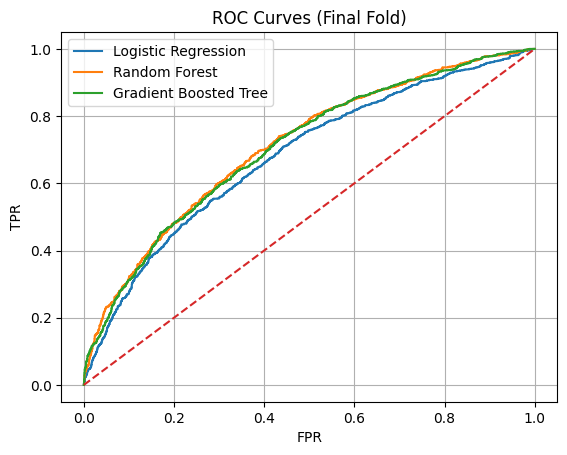

In [39]:
last_fold = max(all_predictions.keys())

plot_roc_curves(all_predictions[last_fold])

In [40]:
stability = (
    df_results
    .groupby("model")["auc"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

stability["stability_score"] = stability["mean"] - stability["std"]

print(stability)

                           mean       std  stability_score
model                                                     
Gradient Boosted Tree  0.713684  0.012663         0.701021
Random Forest          0.711437  0.008197         0.703240
Logistic Regression    0.689367  0.016269         0.673098


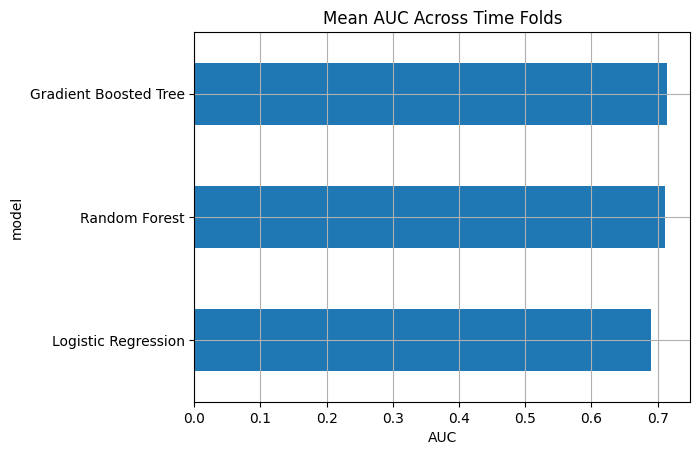

In [41]:
def plot_mean_auc(df):

    summary = df.groupby("model")["auc"].mean().sort_values()

    plt.figure()
    summary.plot(kind="barh")

    plt.title("Mean AUC Across Time Folds")
    plt.xlabel("AUC")
    plt.grid()
    plt.show()


plot_mean_auc(df_results)